# Energy Data Analysis

#### Dataset Used : Hebrail, G. & Berard, A. (2006). Individual Household Electric Power Consumption [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C58K54.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pd.set_option('display.max_rows', None)

## 1. Loading Data

In [ ]:
energy_data = pd.read_csv('Dataset/household_power_consumption.txt', sep = ';', dtype = str)

## 2. Exploring Data

In [4]:
energy_data.shape

(2075259, 9)

In [5]:
energy_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype
---  ------                 -----
 0   Date                   str  
 1   Time                   str  
 2   Global_active_power    str  
 3   Global_reactive_power  str  
 4   Voltage                str  
 5   Global_intensity       str  
 6   Sub_metering_1         str  
 7   Sub_metering_2         str  
 8   Sub_metering_3         str  
dtypes: str(9)
memory usage: 142.5 MB


In [6]:
energy_data.isna().sum()

Date                         0
Time                         0
Global_active_power          0
Global_reactive_power        0
Voltage                      0
Global_intensity             0
Sub_metering_1               0
Sub_metering_2               0
Sub_metering_3           25979
dtype: int64

In [7]:
energy_data = energy_data.dropna()

In [8]:
energy_data.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.000
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.000
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.000
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.000
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.000


## 3. Transforming Data

### 1. Converting to proper datetime index

In [9]:
energy_data['date_time'] = energy_data['Date'] + ' ' + energy_data['Time']

In [10]:
energy_data['date_time'] = pd.to_datetime(energy_data['date_time'], 
                                          format='%d/%m/%Y %H:%M:%S')

In [11]:
energy_data = energy_data.set_index('date_time')

In [12]:
energy_data = energy_data.drop(columns = ['Date', 'Time'])

### 2. Converting all the columns to numeric

In [13]:
energy_data['Global_active_power'] = pd.to_numeric(energy_data['Global_active_power'], 
                                                   errors = 'coerce')

In [14]:
energy_data['Global_reactive_power'] = pd.to_numeric(energy_data['Global_reactive_power'], 
                                                     errors = 'coerce')

In [15]:
energy_data['Voltage'] = pd.to_numeric(energy_data['Voltage'], 
                                       errors = 'coerce')

In [16]:
energy_data['Global_intensity'] = pd.to_numeric(energy_data['Global_intensity'], 
                                                errors = 'coerce')

In [17]:
energy_data['Sub_metering_1'] = pd.to_numeric(energy_data['Sub_metering_1'], 
                                              errors = 'coerce')

In [18]:
energy_data['Sub_metering_2'] = pd.to_numeric(energy_data['Sub_metering_2'], 
                                              errors = 'coerce')

In [19]:
energy_data['Sub_metering_3'] = pd.to_numeric(energy_data['Sub_metering_3'], 
                                              errors = 'coerce')

### 3. Calculating energy consumed by rest of appliances

In [20]:
energy_data['Rest_appliances_metering'] = (energy_data['Global_active_power'] * 1000 / 60- 
                                           energy_data['Sub_metering_1'] - 
                                           energy_data['Sub_metering_2'] - 
                                           energy_data['Sub_metering_3'])

In [152]:
energy_data.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Rest_appliances_metering
date_time,,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,52.266667
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,72.333333
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,70.566667
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,71.800000
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,43.100000


## 4. Basic Stats

In [148]:
print('-------Global_active_power (kW) Stats-------')
print('Global_active_power mean:    ', energy_data['Global_active_power'].mean().round(3))
print('Global_active_power minimum: ', energy_data['Global_active_power'].min().round(3))
print('Global_active_power maximum: ', energy_data['Global_active_power'].max().round(3))
print('Global_active_power std:     ', energy_data['Global_active_power'].std().round(3))

-------Global_active_power (kW) Stats-------
Global_active_power mean:     1.092
Global_active_power minimum:  0.076
Global_active_power maximum:  11.122
Global_active_power std:      1.057


In [150]:
print('-------Sub Meters Energy (wh) Stats-------')

print('\n---------Mean---------')
print(energy_data[['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']].mean())
print('\n---------Minimum---------')
print(energy_data[['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']].min())
print('\n---------Maximum---------')
print(energy_data[['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']].max())
print('\n---------Std---------')
print(energy_data[['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']].std())


-------Sub Meters Energy (wh) Stats-------

---------Mean---------
Sub_metering_1    1.121923
Sub_metering_2    1.298520
Sub_metering_3    6.458447
dtype: float64

---------Minimum---------
Sub_metering_1    0.0
Sub_metering_2    0.0
Sub_metering_3    0.0
dtype: float64

---------Maximum---------
Sub_metering_1    88.0
Sub_metering_2    80.0
Sub_metering_3    31.0
dtype: float64

---------Std---------
Sub_metering_1    6.153031
Sub_metering_2    5.822026
Sub_metering_3    8.437154
dtype: float64


In [25]:
total_global_power = energy_data['Global_active_power'].sum() * 1000 / 60
total_sub_meter_1 = energy_data['Sub_metering_1'].sum()
total_sub_meter_2 = energy_data['Sub_metering_2'].sum()
total_sub_meter_3 = energy_data['Sub_metering_3'].sum()
total_rest_meter = energy_data['Rest_appliances_metering'].sum()

In [153]:
print('----Percentage Of Total Global Active Power----')
print('Sub_meter_1:              ', round((total_sub_meter_1 / total_global_power) * 100, 2), '%')
print('Sub_meter_2:              ', round((total_sub_meter_2 / total_global_power) * 100, 2), '%')
print('Sub_meter_3:              ', round((total_sub_meter_3 / total_global_power) * 100, 2), '%')
print('Rest_appliances_metering: ', round((total_rest_meter / total_global_power) * 100, 2), '%')

----Percentage Of Total Global Active Power----
Sub_meter_1:               6.17 %
Sub_meter_2:               7.14 %
Sub_meter_3:               35.5 %
Rest_appliances_metering:  51.2 %


## 5. Basic Visualizations

In [158]:
daily_avg_energy_consumption = (energy_data['Global_active_power'].resample('D').mean() * 24)

In [166]:
rolling_avg = daily_avg_energy_consumption.rolling(window = 7).mean()

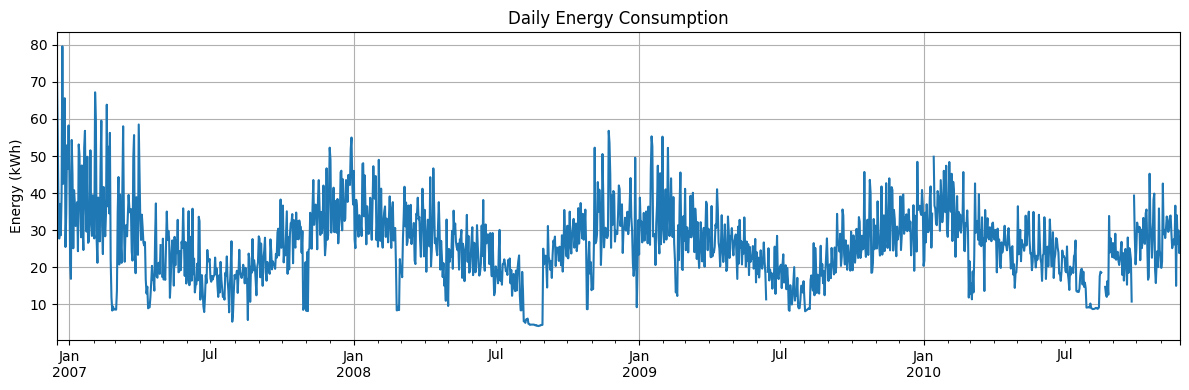

In [164]:
daily_avg_energy_consumption.plot(
    figsize = (12, 4),
    grid = True,
    title = 'Daily Energy Consumption',
    ylabel = 'Energy (kWh)',
    xlabel = ''
)

plt.tight_layout()

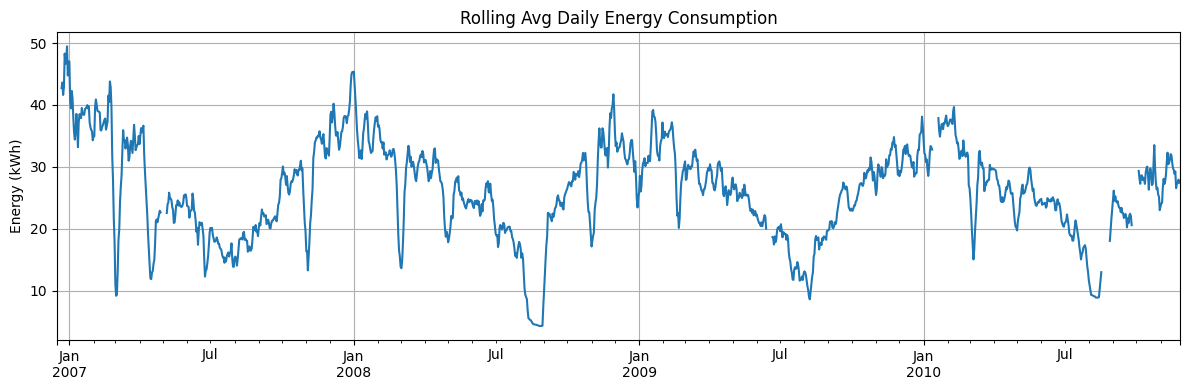

In [167]:
rolling_avg.plot(
    figsize = (12, 4),
    grid = True,
    title = 'Rolling Avg Daily Energy Consumption',
    xlabel = '',
    ylabel = 'Energy (kWh)'
)

plt.tight_layout()

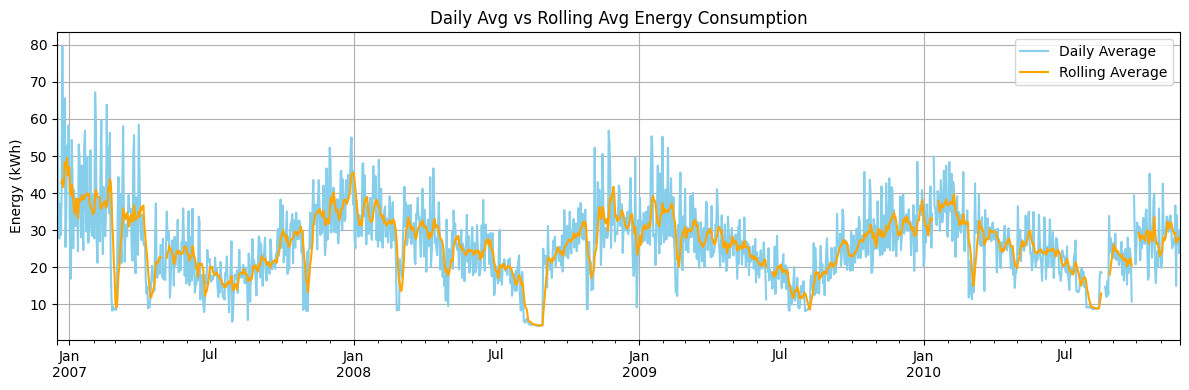

In [187]:
fig, ax = plt.subplots(figsize=(12, 4))

daily_avg_energy_consumption.plot(
    ax=ax,
    label='Daily Average',
    color='skyblue',
    grid=True
)

rolling_avg.plot(
    ax=ax,
    label='Rolling Average',
    color='orange',
    grid = True
)

ax.set_title('Daily Avg vs Rolling Avg Energy Consumption')
ax.set_ylabel('Energy (kWh)')
ax.set_xlabel('')
ax.legend()

plt.tight_layout()

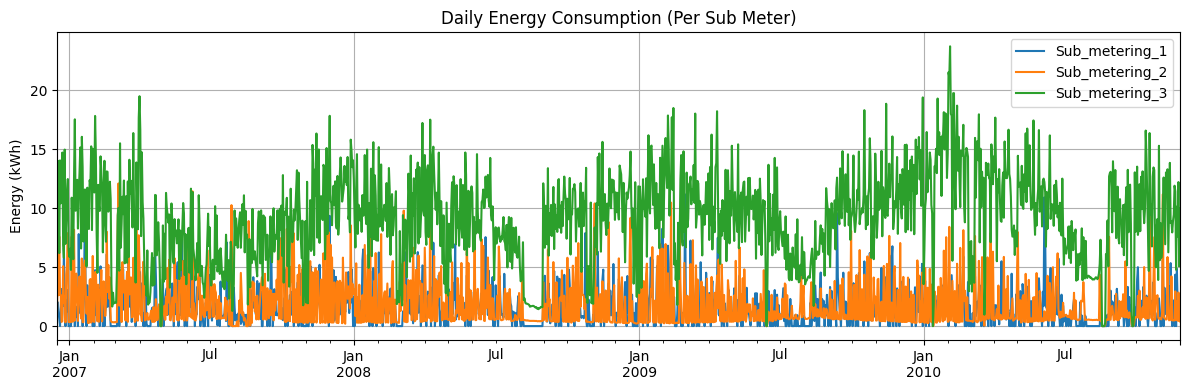

In [183]:
(energy_data[['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']].resample('D').sum() / 1000).plot(
    figsize = (12, 4),
    grid = True,
    title = 'Daily Energy Consumption (Per Sub Meter)',
    ylabel = 'Energy (kWh)',
    xlabel = ''
)

plt.tight_layout()

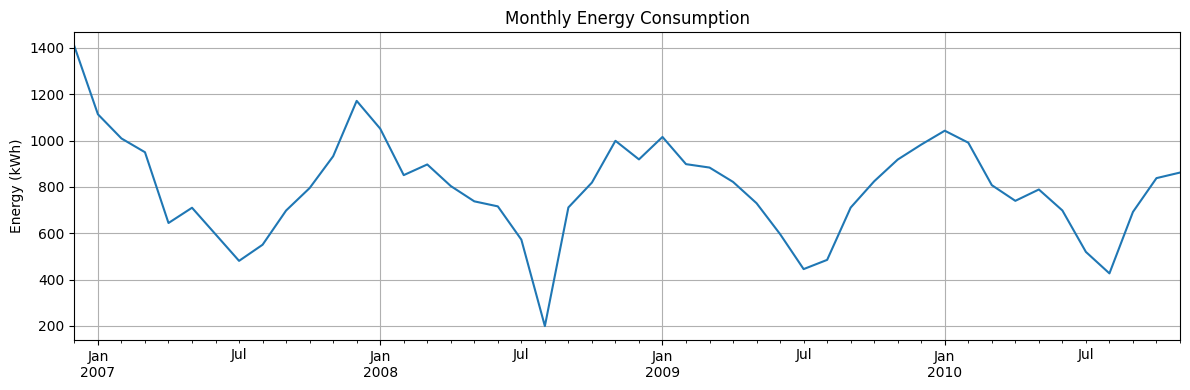

In [142]:
(daily_avg_energy_consumption.resample('ME').mean() * 30).plot(
    figsize = (12, 4),
    grid = True,
    title = 'Monthly Energy Consumption',
    xlabel = '',
    ylabel = 'Energy (kWh)'
)

plt.tight_layout()

## 6. Hourly Analysis

In [91]:
hourly_energy_pattern = energy_data.groupby(energy_data.index.hour)['Global_active_power'].mean()

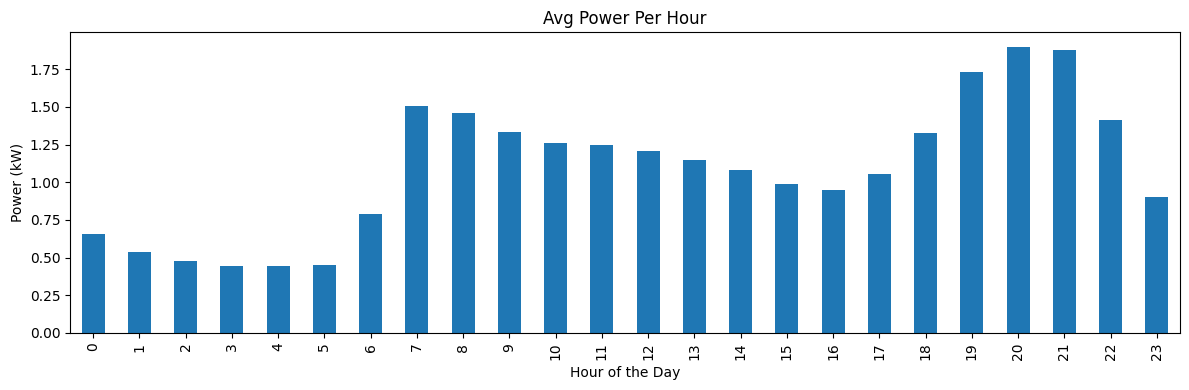

In [99]:
hourly_energy_pattern.plot(
    kind = 'bar', 
    figsize = (12, 4), 
    title = 'Avg Power Per Hour',
    xlabel = 'Hour of the Day',
    ylabel = 'Power (kW)'
)

plt.tight_layout()

In [97]:
daily_energy_pattern = energy_data.groupby(energy_data.index.dayofweek)['Global_active_power'].mean()

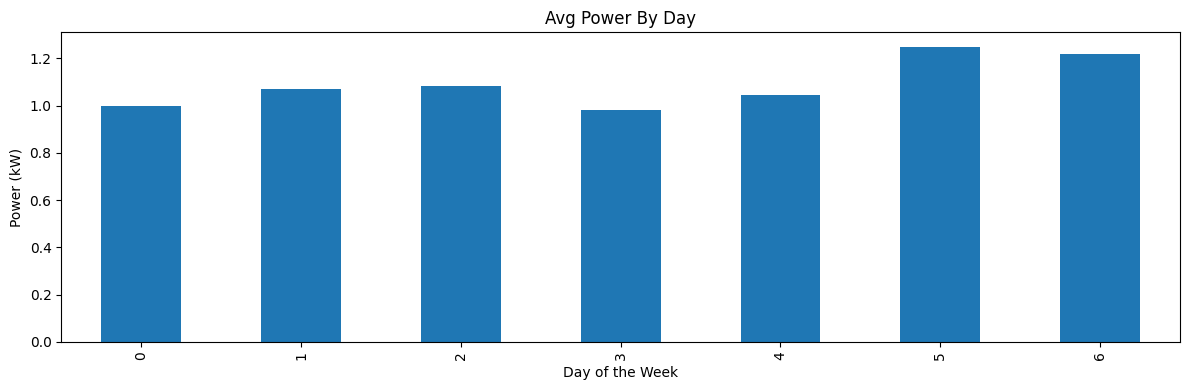

In [100]:
daily_energy_pattern.plot(
    kind = 'bar', 
    figsize = (12, 4), 
    title = 'Avg Power By Day',
    xlabel = 'Day of the Week',
    ylabel = 'Power (kW)'
)


plt.tight_layout()

## 7. Anomaly Detection

In [184]:
mean_consumption_daily = daily_avg_energy_consumption.mean()
std_consumption_daily = daily_avg_energy_consumption.std()
threshold = mean_consumption_daily + (std_consumption_daily * 2)

In [185]:
anomalies = daily_avg_energy_consumption[daily_avg_energy_consumption > threshold]

In [186]:
anomalies.sort_index()

date_time
2006-12-16    73.283394
2006-12-17    56.507667
2006-12-23    79.556433
2006-12-26    65.568500
2006-12-29    52.906533
2006-12-30    46.553024
2006-12-31    58.236600
2007-01-04    54.323533
2007-01-13    53.113567
2007-01-14    50.165104
2007-01-17    47.461467
2007-01-20    52.228867
2007-01-21    56.787700
2007-01-24    49.797567
2007-01-28    51.539191
2007-02-03    67.162033
2007-02-04    59.932333
2007-02-10    47.155467
2007-02-11    59.520467
2007-02-18    63.829367
2007-02-20    52.498800
2007-02-22    56.236072
2007-03-11    58.010600
2007-03-24    49.473833
2007-03-25    55.640706
2007-03-31    58.491833
2007-04-01    46.432533
2007-11-27    46.683533
2007-12-01    52.249033
2007-12-02    49.103133
2007-12-28    51.884200
2007-12-29    54.982600
2008-01-12    47.856800
2008-01-13    48.060976
2008-01-26    47.249800
2008-02-02    48.967905
2008-04-12    46.666900
2008-11-05    52.248833
2008-11-15    50.527133
2008-11-23    56.794841
2008-11-24    53.549967
2008-1